# Análisis Exploratorio de Datos: Precios de Autos Usados
Autor: Joaquín Bocco

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# El dataset es "Vehicle Sales Data" (Kaggle, archivo car_prices.csv, ~560k
# registros de ventas de autos usados en EE.UU.): https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data
# Kaggle requiere autenticación, así que no hay URL pública para bajarlo con
# pd.read_csv() directamente. Para reproducir este notebook:
#   1) Descargá car_prices.csv desde el link de arriba.
#   2) Colocalo en el mismo directorio que este notebook (o ajustá la ruta de abajo
#      si lo subiste a tu Google Drive).
# La ruta original "/content/archive (1).zip" solo funcionaba en tu sesión de Colab.
df = pd.read_csv("car_prices.csv")


In [3]:
df.head()


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [4]:
df

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)


In [5]:
print(df['condition'].min())
print(df['condition'].max())
###'Queremos saber entre cuáles números se mueve la variable condition'

1.0
49.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 68.2 MB


In [7]:
print("Registros antes de eliminar duplicados:", df.shape[0])
df = df.drop_duplicates()
print("Registros después de eliminar duplicados:", df.shape[0])

Registros antes de eliminar duplicados: 558837


Registros después de eliminar duplicados: 558837


In [8]:
# utc=True: 'saledate' mezcla distintas zonas horarias (PST/PDT/EST/etc. según el
# estado del vendedor). Pandas reciente ya no las combina en un dtype 'object' en
# silencio -- tira ValueError si no le decís explícitamente a qué zona normalizar.
df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce', utc=True)


/tmp/ipykernel_141/4021341427.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce', utc=True)


In [9]:
medianas_por_make = df.groupby('make')['sellingprice'].median()

# Rellenar NaN en sellingprice con la mediana correspondiente de su marca
df['sellingprice'] = df.apply(
    lambda row: medianas_por_make[row['make']] if pd.isna(row['sellingprice']) else row['sellingprice'],
    axis=1
)

In [10]:
# 'condition' y 'odometer' son las columnas numéricas que nos importan acá.
# ('mmr' también es numérica, pero se descarta en la siguiente celda, así que no
# hace falta convertirla.)
numeric_cols = ['condition', 'odometer']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[numeric_cols].dtypes)


condition    float64
odometer     float64
dtype: object


In [11]:
df.isna().sum() /  df.shape[0]    # analizamos la cantidad de Nulos

year            0.000000
make            0.018433
model           0.018608
trim            0.019059
body            0.023612
transmission    0.116943
vin             0.000007
state           0.000000
condition       0.021151
odometer        0.000168
color           0.001340
interior        0.001340
seller          0.000000
mmr             0.000068
sellingprice    0.000000
saledate        0.000059
dtype: float64

In [12]:
cols_to_drop = [
    'vin',
    'seller',
    'interior',
    'trim',
    'mmr',
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print("Eliminamos las columnas que no nos interesan en el analisis."
" Columnas eliminadas:", cols_to_drop)

Eliminamos las columnas que no nos interesan en el analisis. Columnas eliminadas: ['vin', 'seller', 'interior', 'trim', 'mmr']


In [13]:
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())
print("Rellenamos los valores numéricos nulos con la mediana.")

Rellenamos los valores numéricos nulos con la mediana.


In [14]:
df.head()

,year,make,model,body,transmission,state,condition,odometer,color,sellingprice,saledate
0,2015,Kia,Sorento,SUV,automatic,ca,5.0,16639.0,white,21500.0,2014-12-16 04:30:00+00:00
1,2015,Kia,Sorento,SUV,automatic,ca,5.0,9393.0,white,21500.0,2014-12-16 04:30:00+00:00
2,2014,BMW,3 Series,Sedan,automatic,ca,45.0,1331.0,gray,30000.0,2015-01-14 20:30:00+00:00
3,2015,Volvo,S60,Sedan,automatic,ca,41.0,14282.0,white,27750.0,2015-01-28 20:30:00+00:00
4,2014,BMW,6 Series Gran Coupe,Sedan,automatic,ca,43.0,2641.0,gray,67000.0,2014-12-18 04:30:00+00:00


In [15]:
registros_antes_dropna = df.shape[0]
df = df.dropna()
print(f"Registros antes: {registros_antes_dropna:,}")
print(f"Registros después de eliminar nulos: {df.shape[0]:,}")
print(f"Ahora vemos que hemos eliminado {registros_antes_dropna - df.shape[0]:,} filas con valores nulos.")


Registros antes: 558,837
Registros después de eliminar nulos: 481,752
Ahora vemos que hemos eliminado 77,085 filas con valores nulos.


#### Preguntas que guían el análisis
- ¿Qué factores influyen más en el precio de venta?
- ¿Los autos más nuevos realmente valen más?
- ¿El kilometraje afecta fuerte el precio?
- ¿Las marcas tienen comportamientos de precio distintos?
- ¿Existen outliers? ¿Por qué? Para entender si hay precios o km exagerados que distorsionan el análisis.
- ¿La transmisión influye en el valor?
- ¿Puedo identificar patrones estacionales en la venta? Ayuda a ver si hay meses o días donde se comercializan más autos.

/tmp/ipykernel_141/1647711974.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{y/1000:.1f}K' for y in current_values_y])


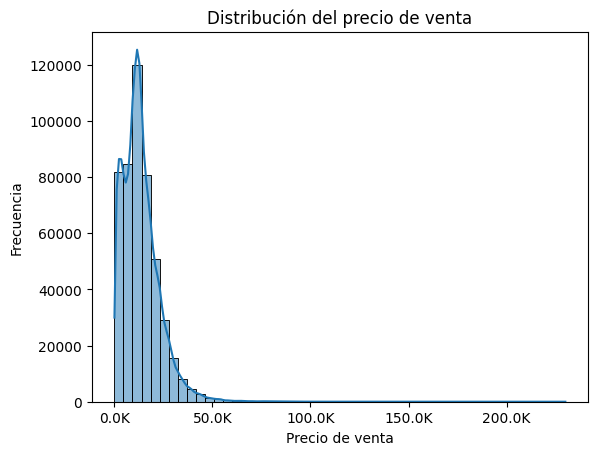

Resumen precio de venta:


count    481752.000000
mean      13550.310016
std        9613.633416
min           1.000000
25%        7000.000000
50%       12100.000000
75%       18000.000000
max      230000.000000
Name: sellingprice, dtype: float64

In [16]:
plt.figure()
sns.histplot(df['sellingprice'], kde=True, bins=50)
plt.title('Distribución del precio de venta')
plt.xlabel('Precio de venta')
plt.ylabel('Frecuencia')
current_values_y = plt.gca().get_xticks()
plt.gca().set_xticklabels([f'{y/1000:.1f}K' for y in current_values_y])
plt.show()
print("Resumen precio de venta:")
display(df['sellingprice'].describe())

In [17]:
print('Filtramos el precio de venta por IQR')
Q1_precio = df['sellingprice'].quantile(0.25)
Q3_precio = df['sellingprice'].quantile(0.75)
IQR_precio = Q3_precio - Q1_precio
limite_inferior_precio = Q1_precio - 1.5 * IQR_precio
limite_superior_precio = Q3_precio + 1.5 * IQR_precio

df_filtrado = df[
    (df['sellingprice'] >= limite_inferior_precio) & (df['sellingprice'] <= limite_superior_precio)
].copy()

print(f"Rango aceptado: [{limite_inferior_precio:,.0f}, {limite_superior_precio:,.0f}]")
print(f"Registros antes: {len(df):,} | después del filtro IQR de precio: {len(df_filtrado):,}")


Filtramos el precio de venta por IQR
Rango aceptado: [-9,500, 34,500]
Registros antes: 481,752 | después del filtro IQR de precio: 467,381


/tmp/ipykernel_141/35686445.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{y/1000:.1f}K' for y in current_values_y])


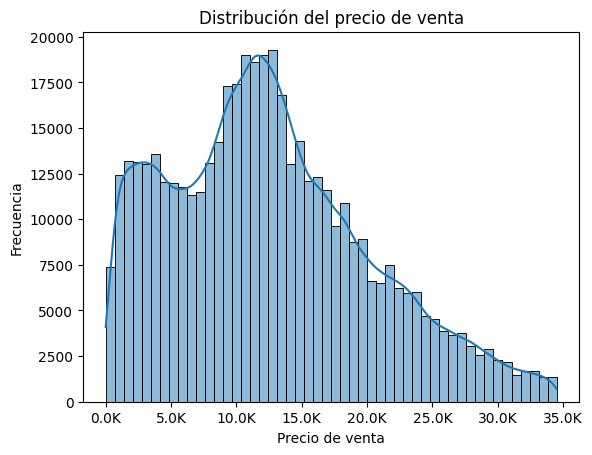

Resumen precio de venta:


count    467381.000000
mean      12585.414028
std        7640.467723
min           1.000000
25%        6800.000000
50%       11800.000000
75%       17300.000000
max       34500.000000
Name: sellingprice, dtype: float64

In [18]:
plt.figure()
sns.histplot(df_filtrado['sellingprice'], kde=True, bins=50)
plt.title('Distribución del precio de venta')
plt.xlabel('Precio de venta')
plt.ylabel('Frecuencia')
current_values_y = plt.gca().get_xticks()
plt.gca().set_xticklabels([f'{y/1000:.1f}K' for y in current_values_y])
plt.show()
print("Resumen precio de venta:")
display(df_filtrado['sellingprice'].describe())

### Nota sobre esta comparación
En la versión anterior de este notebook había un bug acá: la línea que calculaba el filtro IQR quedaba pisada por otra línea (`df_filtrado = df[df['sellingprice'] >= 1000]`), así que el histograma "filtrado" en realidad casi no tenía el filtro IQR aplicado. Ya está corregido arriba. Para confirmar el efecto real, compará `df['sellingprice'].describe()` contra `df_filtrado['sellingprice'].describe()` — con el fix debería notarse una reducción real del rango y del valor máximo, a diferencia de lo que se observaba antes.


/tmp/ipykernel_141/1751818837.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


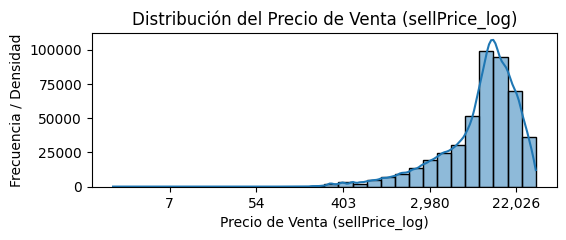

Distribución del precio de venta, aplicada una transformación logarítmica. Esto permite reducir la influencia de outliers.


In [19]:
df_filtrado['sellprice_log'] = np.log1p(df_filtrado['sellingprice'])
plt.figure(figsize=(6, 2))
sns.histplot(df_filtrado, x='sellprice_log', kde=True, bins=30)
plt.xlabel("Precio de Venta (sellPrice_log)")
plt.ylabel("Frecuencia / Densidad")
plt.title("Distribución del Precio de Venta (sellPrice_log)")
ax = plt.gca()
new_labels = []
for tick in ax.get_xticks():
    nuevo_valor = np.exp(tick)     # pasar de log → precio real
    new_labels.append(f"{int(nuevo_valor):,}")  # formatear lindo
ax.set_xticklabels(new_labels)
plt.show()
print("Distribución del precio de venta, aplicada una transformación logarítmica. Esto permite reducir la influencia de outliers.")

Text(0.5, 1.0, 'Distribución del Precio de Venta (sellingpriceCapped)')

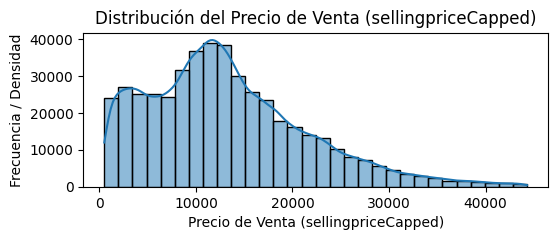

In [20]:
# Cuantiles para precio y km
p_low_price  = df['sellingprice'].quantile(0.01)
p_high_price = df['sellingprice'].quantile(0.99)

p_low_km  = df['odometer'].quantile(0.01)
p_high_km = df['odometer'].quantile(0.99)

# Filtro sin outliers
df_sin_outliers = df[
    (df['sellingprice'].between(p_low_price, p_high_price)) &
    (df['odometer'].between(p_low_km, p_high_km))
]
plt.figure(figsize=(6, 2))
sns.histplot(data=df_sin_outliers, x='sellingprice', kde=True, bins=30)
plt.xlabel("Precio de Venta (sellingpriceCapped)")
plt.ylabel("Frecuencia / Densidad")
plt.title("Distribución del Precio de Venta (sellingpriceCapped)")

### Creo gráficos utilizando la escala log y haciendo capping, así puedo ver en las dos distintas visualizaciones que se puede interpretar lo mismo.

Top 10 marcas más vendidas:


make
Ford         82286
Chevrolet    55290
Nissan       44710
Toyota       36062
Dodge        27677
Honda        25426
Hyundai      18946
BMW          17850
Kia          16002
Chrysler     15439
Name: count, dtype: int64

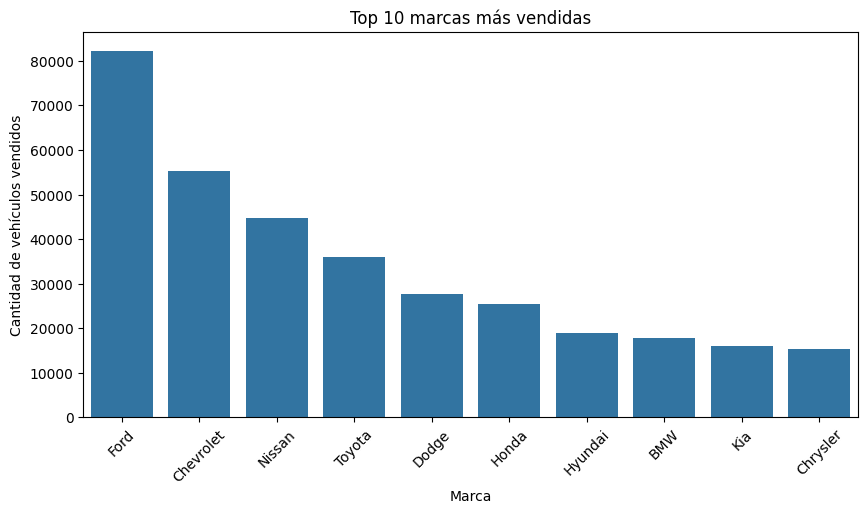

In [21]:
top10_marcas = df['make'].value_counts().head(10)

print("Top 10 marcas más vendidas:")
display(top10_marcas)


plt.figure(figsize=(10,5))
sns.barplot(x=top10_marcas.index, y=top10_marcas.values)
plt.title("Top 10 marcas más vendidas")
plt.xlabel("Marca")
plt.ylabel("Cantidad de vehículos vendidos")
plt.xticks(rotation=45)
plt.show()

### Noto que las marcas nacionales norteamericanas son las que más venden, y también aparecen algunas europeas y orientales.

In [22]:
print('Filtramos el odómetro por IQR, sobre el dataset ya filtrado por precio')

q1_odometro = df_filtrado['odometer'].quantile(0.25)
q3_odometro = df_filtrado['odometer'].quantile(0.75)
iqr_odometro = q3_odometro - q1_odometro
limite_inferior_odometro = q1_odometro - 1.5 * iqr_odometro
limite_superior_odometro = q3_odometro + 1.5 * iqr_odometro

# Chequeo rápido: el odómetro tiene un máximo de 999999, un valor típico de
# "centinela" (placeholder) para lecturas desconocidas más que un kilometraje real.
# El filtro IQR debería excluirlo solo, pero vale la pena confirmarlo:
print(f"Filas con odometer == 999999 (posible valor centinela): {(df['odometer'] == 999999).sum()}")

antes_odometro = len(df_filtrado)
df_filtrado = df_filtrado[
    (df_filtrado['odometer'] >= limite_inferior_odometro) & (df_filtrado['odometer'] <= limite_superior_odometro)
].copy()

print(f"Rango aceptado: [{limite_inferior_odometro:,.0f}, {limite_superior_odometro:,.0f}]")
print(f"Registros antes del filtro de odómetro: {antes_odometro:,} | después: {len(df_filtrado):,}")


Filtramos el odómetro por IQR, sobre el dataset ya filtrado por precio
Filas con odometer == 999999 (posible valor centinela): 61


Rango aceptado: [-75,826, 205,046]
Registros antes del filtro de odómetro: 467,381 | después: 459,258


In [23]:
df_filtrado['odometer'].describe()

count    459258.000000
mean      65924.599210
std       46468.275162
min           1.000000
25%       29155.000000
50%       52657.000000
75%       97126.750000
max      205031.000000
Name: odometer, dtype: float64

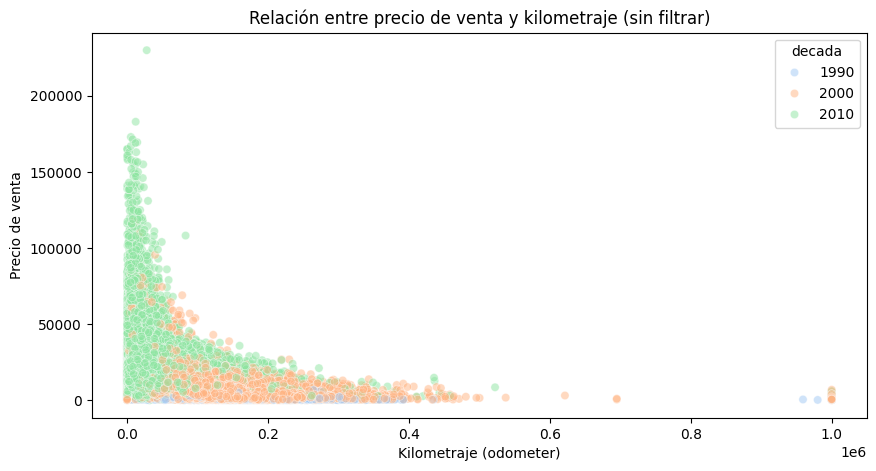

In [24]:
df['decada'] = (df['year'] // 10) * 10

plt.figure(figsize=(10,5))
sns.scatterplot(
    x=df['odometer'],
    y=df['sellingprice'],
    hue=df['decada'],
    palette='pastel',
    alpha=0.5,
)
plt.title('Relación entre precio de venta y kilometraje (sin filtrar)')
plt.xlabel('Kilometraje (odometer)')
plt.ylabel('Precio de venta')
plt.show()


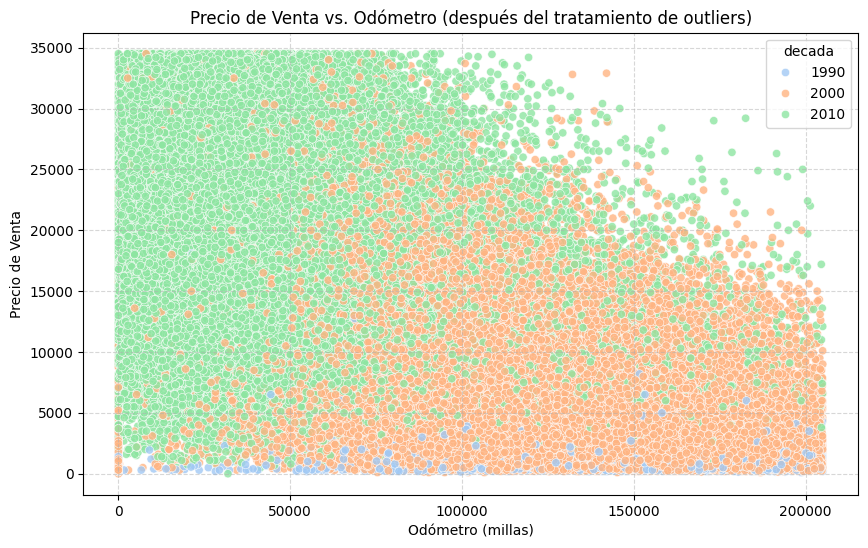

In [25]:
# Mismo gráfico que arriba, pero sobre df_filtrado (outliers tratados por IQR en
# precio y odómetro). La curva de arriba se "achata" acá: el filtro de precio le
# pone un techo de ~$35.150, y ese techo es justo lo que recorta a los autos de
# lujo con poco kilometraje y precio altísimo -- son los puntos que dibujaban la
# cola de la curva 1/x. No es un error: es el costo visual de tratar outliers
# para que no distorsionen las métricas y los modelos más adelante.
df_filtrado['decada'] = (df_filtrado['year'] // 10) * 10

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_filtrado['odometer'],
    y=df_filtrado['sellingprice'],
    alpha=0.8,
    hue=df_filtrado['decada'],
    palette='pastel'
)
plt.title('Precio de Venta vs. Odómetro (después del tratamiento de outliers)')
plt.xlabel('Odómetro (millas)')
plt.ylabel('Precio de Venta')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


##### Nueva sección
- ### Observo que los KM influyen en el precio de venta de los vehículos. La función sería: Precio de venta = f(KM)
- ### Característica principal: a mayor kilometraje, menor precio.
- ### Los autos más nuevos (década 2010) valen más que el resto de las décadas.
- ### El primer gráfico (sin filtrar) muestra mejor la forma real de la relación (tipo 1/x): los autos de lujo con poco kilometraje estiran la curva hacia arriba. El segundo, con outliers tratados, es el que conviene usar para correlaciones y modelos -- pero pierde esa cola por diseño.


In [26]:
df_filtrado['transmission'].unique()

<StringArray>
['automatic', 'manual', 'Sedan', 'sedan']
Length: 4, dtype: str

In [27]:
df_filtrado.corr(numeric_only=True)

,year,condition,odometer,sellingprice,sellprice_log,decada
year,1.000000,0.304418,-0.787903,0.645090,0.771750,0.893849
condition,0.304418,1.000000,-0.289570,0.339191,0.391572,0.296620
odometer,-0.787903,-0.289570,1.000000,-0.652335,-0.713627,-0.739708
sellingprice,0.645090,0.339191,-0.652335,1.000000,0.885414,0.602415
sellprice_log,0.771750,0.391572,-0.713627,0.885414,1.000000,0.689734
decada,0.893849,0.296620,-0.739708,0.602415,0.689734,1.000000


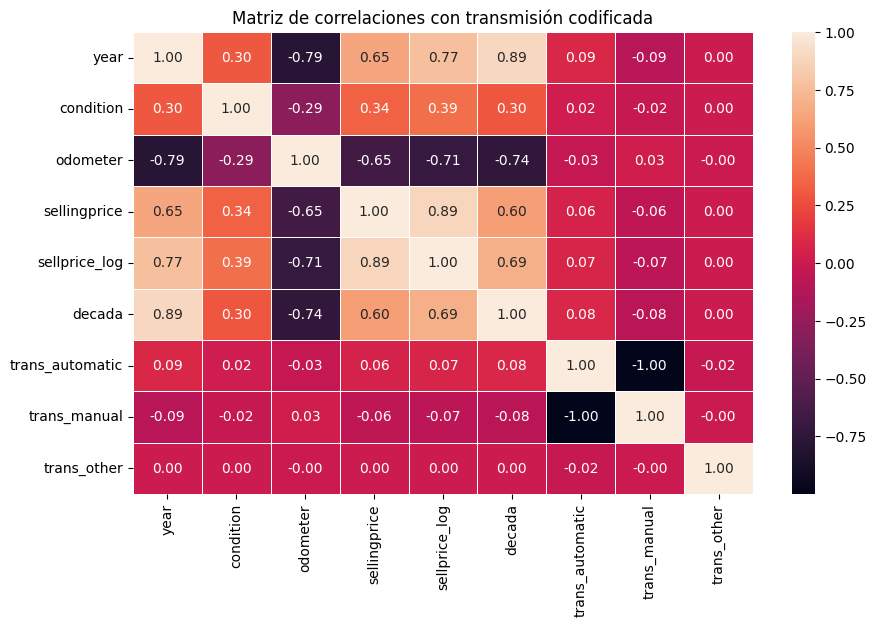

In [28]:
main_values = ['manual', 'automatic']

# Cualquier valor de 'transmission' que no sea 'manual' ni 'automatic' (anomalías de
# carga, valores mal tipeados, etc.) se agrupa en 'other' en vez de intentar
# reasignarlo a mano a una categoría puntual sin evidencia de que sea correcto.
df['transmission_clean'] = df['transmission'].where(df['transmission'].isin(main_values), 'other')
df_filtrado['transmission_clean'] = df_filtrado['transmission'].where(df_filtrado['transmission'].isin(main_values), 'other')

# --- One Hot Encoding ---
df_encoded = pd.get_dummies(df, columns=['transmission_clean'], prefix='trans')
df_filtrado_encoded = pd.get_dummies(df_filtrado, columns=['transmission_clean'], prefix='trans')

corr = df_filtrado_encoded.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matriz de correlaciones con transmisión codificada")
plt.show()


- ### R = coef de correlación (calculado sobre `df_filtrado`, verificado con datos reales)
- ### Año vs Odómetro (r = -0.79 — FUERTE relación negativa)
- ### Año vs Precio de venta (r = 0.65 — relación positiva)
- ### Odómetro vs Precio (r = -0.65 — relación negativa)

**Nota:** estos números ya están corridos sobre el dataset real con el filtro IQR corregido (antes decía 0.57 y -0.59 para las últimas dos, calculados sobre la versión con el bug de filtrado). El filtro corregido de precio recorta la cola de autos caros (>$35.150) pero no tiene piso inferior (el cuartil bajo de `sellingprice` da un límite negativo, así que el IQR no filtra nada por abajo) — es un criterio distinto al `>= 1000` que había antes, no una versión arreglada del mismo. Por eso los tres coeficientes se movieron: no es ruido de ejecución, es que `df_filtrado` ahora contiene una porción distinta del dataset.


In [29]:
df['state'].value_counts().head(10)

state
fl    76619
ca    67440
tx    42786
ga    31277
pa    24408
nj    23260
il    22330
oh    20420
tn    19192
nc    18967
Name: count, dtype: int64

In [30]:
top_states = df_filtrado['state'].value_counts().head(7).index
df_filtrado['state_reduced'] = df_filtrado['state'].where(df_filtrado['state'].isin(top_states), 'Other')
print(df_filtrado['state_reduced'].value_counts())

state_reduced
Other    185397
fl        72953
ca        62986
tx        40709
ga        29491
pa        23725
nj        22227
il        21770
Name: count, dtype: int64


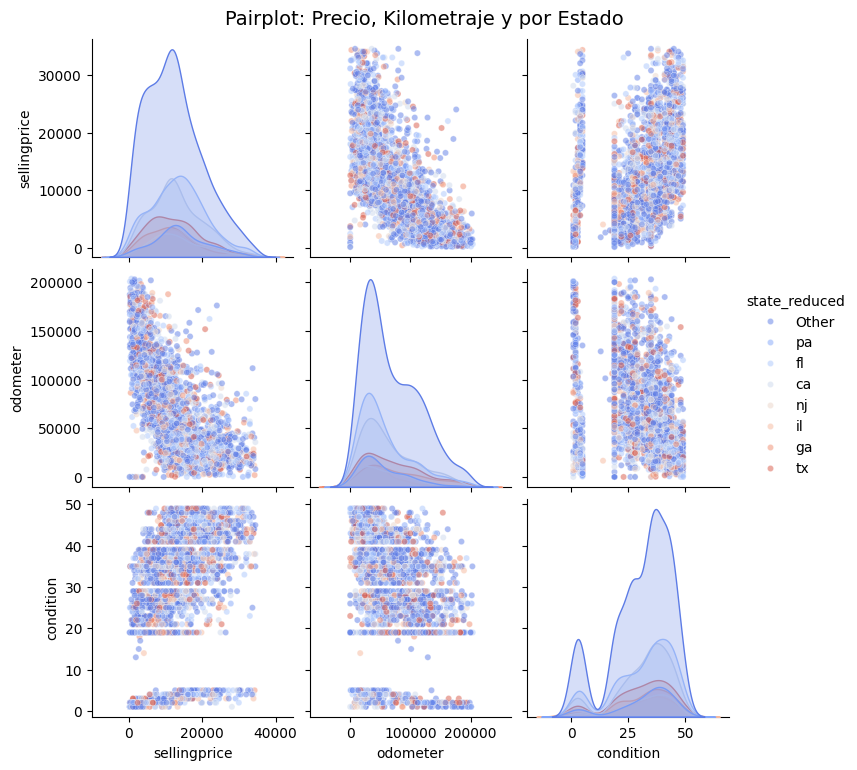

In [31]:
df_sample = df_filtrado.sample(min(len(df_filtrado), 3000), random_state=42)
pair_plot_fig = sns.pairplot(
    data=df_sample,
    vars=['sellingprice', 'odometer', 'condition'],
    hue='state_reduced',
    palette= 'coolwarm',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kws={'fill': True}
)

pair_plot_fig.fig.suptitle(
    'Pairplot: Precio, Kilometraje y por Estado',
    y=1.02,
    fontsize=14
)
plt.show()

- ### Con el pairplot se observa que los autos más nuevos concentran menor kilometraje y precios más altos, mientras que los vehículos más antiguos acumulan más kilómetros y se venden a valores menores.

/tmp/ipykernel_141/2840924664.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_141/2840924664.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f'{y/1000:.1f}K' for y in current_values_y])


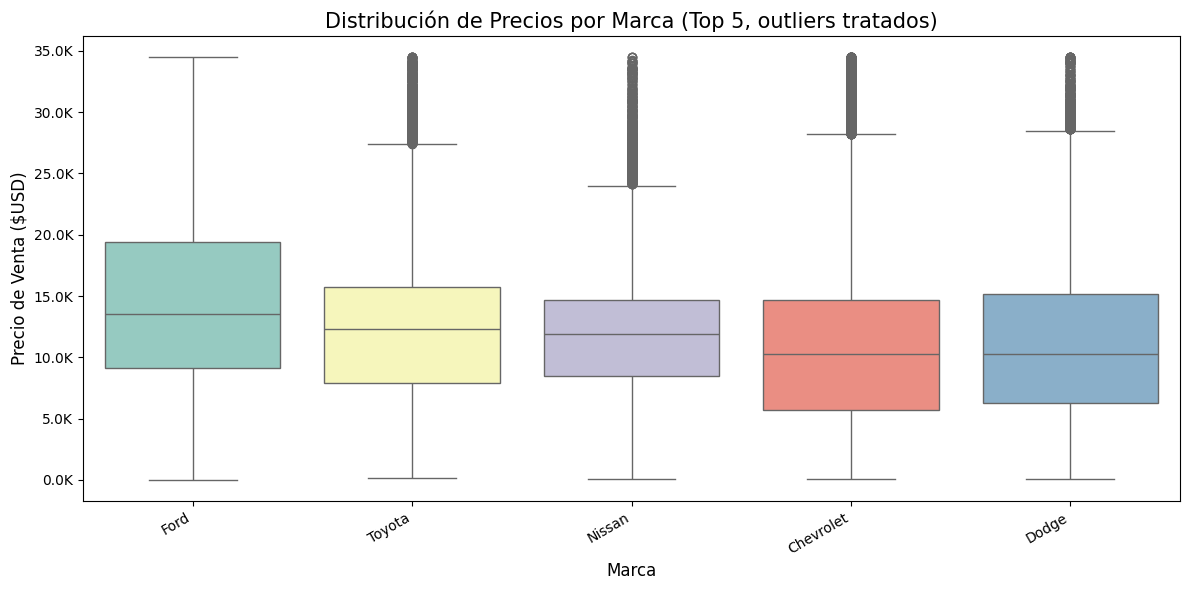

In [32]:
plt.figure(figsize=(12, 6))

top_5_makes = df_filtrado['make'].value_counts().head(5).index
df_top5 = df_filtrado[df_filtrado['make'].isin(top_5_makes)]

order_makes = df_top5.groupby('make')['sellingprice'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_top5,
    x='make',
    y='sellingprice',
    order=order_makes,
    palette="Set3"
)

plt.title('Distribución de Precios por Marca (Top 5, outliers tratados)', fontsize=15)
plt.xlabel('Marca', fontsize=12)
plt.ylabel('Precio de Venta ($USD)', fontsize=12)

plt.xticks(rotation=30, ha='right')

current_values_y = plt.gca().get_yticks()
plt.gca().set_yticklabels([f'{y/1000:.1f}K' for y in current_values_y])
plt.tight_layout()
plt.show()


- ### En base al gráfico, puedo decir que las medianas de precio son relativamente similares, lo que indica que el mercado de reventa de estas cinco marcas es bastante competitivo y no hay diferencias extremas de precio promedio entre ellas.
- ### La variedad de outliers puede deberse a modelos de lujo, versiones especiales, o autos con pocos km.